# Tutorial: QOS Quickstart

Audience:
- Readers who want to run quantum oracle sketching (QOS) without digging through all internals first.

Prerequisites:
- Python environment with `pip install -r requirements.txt`
- Basic familiarity with vectors/matrices and norm-based error metrics

Learning goals:
- Build and evaluate three QOS primitives from small toy data.
- Understand how sample size affects approximation error.
- Leave with a minimal template you can adapt to your own experiments.


## Outline

1. Setup and imports
2. Boolean phase-oracle sketch
3. General-vector state sketch
4. Sparse matrix-element oracle sketch
5. Sweep sample size, fit scaling exponent, and visualize error
6. Exercises


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import jax.numpy as jnp
from jax import random
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve()
if not (ROOT / "qos.py").exists() and (ROOT.parent / "qos.py").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import qos
import utils

SEED = 0
key = random.PRNGKey(SEED)

print("Repository root:", ROOT)
print("Seed:", SEED)


Repository root: /Users/hmzhao/Documents/课题/streaming/code
Seed: 0


## Step 1 - Boolean phase-oracle sketch

We sketch a phase oracle for a random Boolean truth table and measure the max elementwise error against the exact diagonal oracle.


In [2]:
dim = 64
unit_num_samples = int(1e5)

key, subkey = random.split(key)
truth_table = random.randint(subkey, (dim,), minval=0, maxval=2, dtype=utils.int_dtype)

diag_est, samples_used = qos.q_oracle_sketch_boolean(truth_table, unit_num_samples)
bool_target = jnp.exp(1j * jnp.pi * truth_table)

bool_error = jnp.max(jnp.abs(diag_est - bool_target))

print(f"Boolean oracle max error: {float(bool_error):.3e}")
print(f"Samples used: {int(samples_used):,}")


Boolean oracle max error: 3.104e-03
Samples used: 100,000


## Step 2 - General-vector state sketch

Now we use a general real vector and sketch its state preparation unitary with `q_state_sketch`.
We report the l2 error of the unnormalized state after renormalization.


In [7]:
dim = 64
unit_num_samples = 20_000

key, subkey = random.split(key)
general_vec = random.normal(subkey, (dim,), dtype=utils.real_dtype)
general_vec = general_vec / jnp.linalg.norm(general_vec)

key, subkey = random.split(key)
with utils.suppress_stdout_stderr():
    state_est, samples_used = qos.q_state_sketch(
        general_vec,
        key=subkey,
        unit_num_samples=unit_num_samples,
    )

state_norm = float(jnp.linalg.norm(state_est))
state_dir = state_est / state_norm
target_dir = general_vec / jnp.linalg.norm(general_vec)

general_l2_error = jnp.linalg.norm(state_dir - target_dir)

print(f"General-vector l2 error: {float(general_l2_error):.3e}")
print(f"Output state norm: {state_norm:.3e}")
print(f"Samples used: {int(samples_used):,}")


[PolyTaylorSeries] (Cheb) average error = 0.002506870511298214 in the domain [-0.8414709848078965, 0.8414709848078965] using degree 4
[sym_qsp] Iterative optimization to err 1.000e-12 or max_iter 100.
iter: 001 --- err: 8.574e-02
iter: 002 --- err: 5.815e-03
iter: 003 --- err: 3.859e-05
iter: 004 --- err: 1.755e-09
iter: 005 --- err: 2.429e-16
[sym_qsp] Stop criteria satisfied.
General-vector l2 error: 6.387e-03
Output state norm: 1.253e-01
Samples used: 3,000,000


## Step 3 - Sparse matrix-element oracle sketch

We sketch the sparse matrix-element oracle diagonal and compare it to the original matrix entries.


In [8]:
dim = 24
nnz = 120
unit_num_samples = int(1e5)

key, subkey = random.split(key)
A = utils.random_sparse_matrix_constant_magnitude(
    subkey,
    (dim, dim),
    nnz=nnz,
    magnitude=0.5,
)

diag_est, samples_used = qos.q_oracle_sketch_matrix_element(
    A, unit_num_samples=unit_num_samples
)
matrix_target = A.reshape(-1)

mat_error = jnp.max(jnp.abs(diag_est - matrix_target))

print(f"Matrix shape: {A.shape}, nnz: {int(jnp.count_nonzero(A))}")
print(f"Matrix element-oracle max error: {float(mat_error):.3e}")
print(f"Samples used: {int(samples_used):,}")


Matrix shape: (24, 24), nnz: 112
Matrix element-oracle max error: 7.568e-05
Samples used: 100,000


## Step 4 - Error vs sample size with fitted scaling exponent

We sweep sample size `M` for the Boolean oracle, then fit a power law
`error ~ C * M^{-beta}`
using linear regression in log-log space.


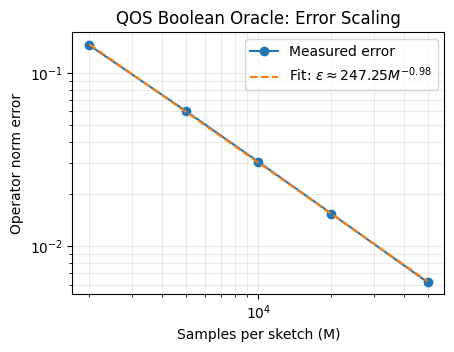

Fitted exponent beta: 0.9780
Fitted prefactor C: 2.4725e+02
Log-space R^2: 0.9999
M=  2000 -> error=1.439e-01, fit=1.461e-01
M=  5000 -> error=6.028e-02, fit=5.962e-02
M= 10000 -> error=3.061e-02, fit=3.027e-02
M= 20000 -> error=1.542e-02, fit=1.536e-02
M= 50000 -> error=6.199e-03, fit=6.271e-03


In [13]:
sample_sizes = np.array([2_000, 5_000, 10_000, 20_000, 50_000], dtype=float)
errors = []

for m in sample_sizes:
    diag_est, _ = qos.q_oracle_sketch_boolean(truth_table, int(m))
    err = jnp.max(jnp.abs(diag_est - bool_target))
    errors.append(float(err))

errors = np.array(errors, dtype=float)

# Fit: log(error) = intercept + slope * log(M)
log_m = np.log(sample_sizes)
log_e = np.log(errors)
slope, intercept = np.polyfit(log_m, log_e, deg=1)

beta = -slope
C = float(np.exp(intercept))
fit_errors = C * sample_sizes**slope

# Goodness of fit in log-space
log_pred = slope * log_m + intercept
ss_res = float(np.sum((log_e - log_pred) ** 2))
ss_tot = float(np.sum((log_e - np.mean(log_e)) ** 2))
r2_log = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")

plt.figure(figsize=(4.8, 3.4))
plt.loglog(sample_sizes, errors, marker="o", linewidth=1.5, label="Measured error")
plt.loglog(
    sample_sizes,
    fit_errors,
    linestyle="--",
    linewidth=1.5,
    label=rf"Fit: $\epsilon \approx {C:.2f} M^{{-{beta:.2f}}}$",
)
plt.xlabel("Samples per sketch (M)")
plt.ylabel("Operator norm error")
plt.title("QOS Boolean Oracle: Error Scaling")
plt.grid(True, which="both", alpha=0.25)
plt.legend()
plt.show()

print(f"Fitted exponent beta: {beta:.4f}")
print(f"Fitted prefactor C: {C:.4e}")
print(f"Log-space R^2: {r2_log:.4f}")
for m, e, ef in zip(sample_sizes.astype(int), errors, fit_errors):
    print(f"M={m:>6d} -> error={e:.3e}, fit={ef:.3e}")


## Exercises

- Increase `dim` in Steps 1-2 and see how much `M` must grow to keep similar error.
- In Step 3, vary `nnz` while fixing matrix shape and observe the effect on reconstruction quality.
- In Step 4, compare the fitted exponent `beta` with your theoretical expectation.
- Replace random data with your own vector/matrix and benchmark practical sample budgets.


In [14]:
def boolean_sweep(
    dim: int = 64, sample_sizes=(2_000, 5_000, 10_000, 20_000), seed: int = 123
):
    key = random.PRNGKey(seed)
    key, subkey = random.split(key)
    truth_table = random.randint(
        subkey, (dim,), minval=0, maxval=2, dtype=utils.int_dtype
    )
    target = jnp.exp(1j * jnp.pi * truth_table)

    out = []
    for m in sample_sizes:
        est, _ = qos.q_oracle_sketch_boolean(truth_table, int(m))
        err = float(jnp.max(jnp.abs(est - target)))
        out.append((int(m), err))
    return out


boolean_sweep()


[(2000, 0.14394090439845544),
 (5000, 0.06028280843425941),
 (10000, 0.030610676053124196),
 (20000, 0.015424397086119944)]